<a href="https://colab.research.google.com/github/KEY-FOX/colab_ex/blob/main/%EC%8B%A4%EC%8A%B51/%EC%8B%A4%EC%8A%B51_%EC%98%88%EC%A0%9C1_SLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **필요한 라이브러리 불러오기**


In [1]:
import torch
import torch.nn as nn

In [2]:
# GPU로 연산.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 랜덤 시드 고정.
# 실험 조건을 동일하게 설정하여,
# 같은 input을 넣으면 같은 결과가 나올 수 있도록 함.
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

# **입력과 출력 정의**

## ✏️ TODO: XOR 입력과 출력 정의하기

PPT에 제시된 XOR의 입력·출력 관계를 참고하여 `X`와 `Y`를 직접 작성하세요.

- `X`: 두 입력값으로 만들 수 있는 네 가지 조합
- `Y`: 각 입력 조합에 대응하는 XOR 결과
- 두 입력이 서로 다르면 `1`, 서로 같으면 `0`을 출력합니다.
- `X`와 `Y`의 데이터 순서가 일치하도록 작성하세요.

In [4]:
X = torch.FloatTensor([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]).to(device)

Y =torch.FloatTensor([
    [0],
    [1],
    [1],
    [0]
]).to(device)

# **단층 퍼셉트론 설계**

## ✏️ TODO: 단층 퍼셉트론 설계하기

PPT에 제시된 SLP 구조를 참고하여 `linear`, `sigmoid`, `model`을 직접 작성하세요.

- `linear`: 입력 2개와 출력 뉴런 1개를 갖는 Linear 계층
- `sigmoid`: 출력값을 0과 1 사이로 변환하는 Sigmoid 활성화 함수
- Linear 계층은 편향을 사용하도록 `bias=True`로 설정하세요.
- `model`은 `nn.Sequential()`을 사용하여 `linear`와 `sigmoid`를 순서대로 연결하세요.
- 생성한 모델을 `.to(device)`로 지정한 연산 장치에 이동하세요.

In [5]:
# 1개의 뉴런을 가지는 SLP(단층 퍼셉트론) 구현.
# 시그모이드 함수 사용.
linear = nn.Linear(2,1,bias=True)
sigmoid = nn.Sigmoid()
model =nn.Sequential(linear,sigmoid).to(device)

# **비용 함수와 옵티마이저 정의**

## ✏️ TODO: 비용 함수와 옵티마이저 정의하기

PPT를 참고하여 모델 학습에 사용할 `criterion`과 `optimizer`를 직접 작성하세요.

- `criterion`: 예측값과 실제 정답의 차이를 계산하는 비용 함수
- Sigmoid 출력으로 이진 분류를 수행하므로 `nn.BCELoss()`를 사용하세요.
- `optimizer`: 비용을 줄이는 방향으로 모델의 가중치를 갱신하는 옵티마이저
- `torch.optim.SGD()`에 `model.parameters()`와 앞에서 설정한 `learning_rate`를 전달하세요.

In [6]:
# 0 또는 1을 예측하는 이진 분류 문제이므로,
# cross entropy 함수 사용.
criterion = torch.nn.BCELoss().to(device)
optimizer = torch.optim.SGD(model.parameters(),lr=1)

# **학습 시작**

## ✏️ TODO: 모델 학습 과정 작성하기

PPT를 참고하여 반복문 안에 모델 학습에 필요한 다섯 단계의 코드를 순서대로 작성하세요.

- 기울기 초기화: 이전 학습 단계에서 계산된 기울기를 초기화하세요.
- 순전파: 입력 `X`를 모델에 전달하고 예측값을 `hypothesis`에 저장하세요.
- 비용 계산: `criterion`으로 예측값과 실제 정답 `Y`의 차이를 계산하여 `cost`에 저장하세요.
- 역전파: `cost`를 기준으로 모델의 학습 가능한 매개변수에 대한 기울기를 계산하세요.
- 가중치 갱신: `optimizer`를 통해 계산된 기울기를 반영하여 가중치를 갱신하세요.

작성한 코드가 반복문 안에서 실행되도록 들여쓰기에 주의하세요.

In [8]:
cost_list = []
total_epoch = [i for i in range(10000) if i%100==0]

# 10,000번의 epoch 수행.
for step in range(1, 10001):
  optimizer.zero_grad()
  hypothesis = model(X)

    # TODO: 이전 단계의 기울기를 초기화하세요.

    # TODO: 입력 X를 모델에 전달하여 hypothesis에 저장하세요.


    # 비용 함수
  cost = criterion(hypothesis, Y)
  cost.backward()
  optimizer.step()
    # TODO: 예측값과 정답 Y의 비용을 계산하여 cost에 저장하세요.

    # TODO: 역전파를 통해 기울기를 계산하세요.

    # TODO: optimizer를 통해 가중치를 갱신하세요.


    # 100번째 epoch마다 비용 출력
  if step % 100 == 0:
      print('Epoch: {}, Cost: {:.4f}'.format(step, cost.item()))
      cost_list.append(cost.item())

Epoch: 100, Cost: 0.6931
Epoch: 200, Cost: 0.6931
Epoch: 300, Cost: 0.6931
Epoch: 400, Cost: 0.6931
Epoch: 500, Cost: 0.6931
Epoch: 600, Cost: 0.6931
Epoch: 700, Cost: 0.6931
Epoch: 800, Cost: 0.6931
Epoch: 900, Cost: 0.6931
Epoch: 1000, Cost: 0.6931
Epoch: 1100, Cost: 0.6931
Epoch: 1200, Cost: 0.6931
Epoch: 1300, Cost: 0.6931
Epoch: 1400, Cost: 0.6931
Epoch: 1500, Cost: 0.6931
Epoch: 1600, Cost: 0.6931
Epoch: 1700, Cost: 0.6931
Epoch: 1800, Cost: 0.6931
Epoch: 1900, Cost: 0.6931
Epoch: 2000, Cost: 0.6931
Epoch: 2100, Cost: 0.6931
Epoch: 2200, Cost: 0.6931
Epoch: 2300, Cost: 0.6931
Epoch: 2400, Cost: 0.6931
Epoch: 2500, Cost: 0.6931
Epoch: 2600, Cost: 0.6931
Epoch: 2700, Cost: 0.6931
Epoch: 2800, Cost: 0.6931
Epoch: 2900, Cost: 0.6931
Epoch: 3000, Cost: 0.6931
Epoch: 3100, Cost: 0.6931
Epoch: 3200, Cost: 0.6931
Epoch: 3300, Cost: 0.6931
Epoch: 3400, Cost: 0.6931
Epoch: 3500, Cost: 0.6931
Epoch: 3600, Cost: 0.6931
Epoch: 3700, Cost: 0.6931
Epoch: 3800, Cost: 0.6931
Epoch: 3900, Cost: 0.

# **단층 퍼셉트론 예측값 확인**

In [10]:
with torch.no_grad():
    hypothesis = model(X)
    predicted = (hypothesis > 0.5).float()
    accuracy = (predicted == Y).float().mean()
    print('모델의 출력값(Hypothesis): \n', hypothesis.detach().cpu().numpy())
    print('모델의 예측값(Predicted): \n', predicted.detach().cpu().numpy())
    print('실제값(Y): \n', Y.cpu().numpy())
    print('정확도(Accuracy): ', accuracy.item())

모델의 출력값(Hypothesis): 
 [[0.5]
 [0.5]
 [0.5]
 [0.5]]
모델의 예측값(Predicted): 
 [[0.]
 [0.]
 [0.]
 [0.]]
실제값(Y): 
 [[0.]
 [1.]
 [1.]
 [0.]]
정확도(Accuracy):  0.5


# **그래프로 cost 변화 확인**

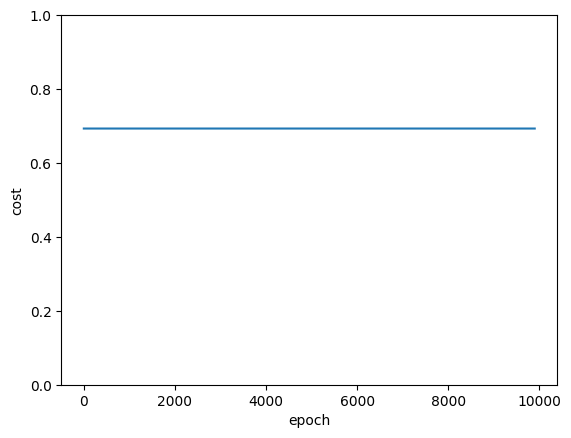

In [11]:
import matplotlib.pyplot as plt

plt.plot(total_epoch, cost_list)
plt.xlabel('epoch')
plt.ylabel('cost')
plt.ylim([0, 1])
plt.show()